# 00 — Smoke Test: MiDaS Inference

Verify that:
- The environment is set up correctly
- MiDaS `dpt_hybrid_384` loads and runs
- GPU is detected (if available)
- `.npy` predictions are saved to `outputs/predictions/smoke/`

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / 'configs' / 'dataset_paths.yaml').exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate project root from the current working directory')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
print(PROJECT_ROOT)

/home/kaiyul3/cs543


In [3]:
import torch
print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [4]:
from pathlib import Path

project_root = Path.home() / "cs543"
print("Project root exists:", project_root.exists())
print("third_party exists:", (project_root / "third_party").exists())
print("MiDaS exists:", (project_root / "third_party" / "MIDAS").exists())
print("MiDaS path:", project_root / "third_party" / "MIDAS")

Project root exists: True
third_party exists: True
MiDaS exists: True
MiDaS path: /home/kaiyul3/cs543/third_party/MIDAS


In [5]:
import sys
from pathlib import Path

project_root = Path.home() / "cs543"

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

if str(project_root / "third_party" / "MIDAS") not in sys.path:
    sys.path.insert(0, str(project_root / "third_party" / "MIDAS"))

print(sys.path[:5])

['/home/kaiyul3/cs543/third_party/MIDAS', '/home/kaiyul3/cs543', '/opt/conda/lib/python313.zip', '/opt/conda/lib/python3.13', '/opt/conda/lib/python3.13/lib-dynload']


In [6]:
import os
PROJECT = Path.home() / "cs543"

weights_dir = f'{PROJECT}/third_party/MIDAS/weights'
os.makedirs(weights_dir, exist_ok=True)

if not os.path.exists(f'{weights_dir}/dpt_hybrid_384.pt'):
    !wget -q -O {weights_dir}/dpt_hybrid_384.pt \
        https://github.com/isl-org/MiDaS/releases/download/v3/dpt_hybrid_384.pt
    print('Downloaded.')
else:
    print('Weights already present.')

Weights already present.


In [9]:
import glob

from src.adapters.midas_adapter import MiDaSAdapter

adapter = MiDaSAdapter(model_type='dpt_hybrid_384')

/opt/conda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/conda/lib/python3.13/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/opt/conda/lib/python3.13/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name vit_base_resnet50_384 to current vit_base_r50_s16_384.orig_in21k_ft_in1k.
  model = create_fn(


Model loaded, number of parameters = 123M
[MiDaSAdapter] Model 'dpt_hybrid_384' loaded on cuda


In [10]:
input_dir = PROJECT_ROOT / 'third_party' / 'MIDAS' / 'input'
image_paths = sorted(
    glob.glob(str(input_dir / '*.jpg')) +
    glob.glob(str(input_dir / '*.png'))
)
print(f'Found {len(image_paths)} images in {input_dir}')
for p in image_paths:
    print(' ', p)

Found 1 images in /home/kaiyul3/cs543/third_party/MIDAS/input
  /home/kaiyul3/cs543/third_party/MIDAS/input/Steam passenger train.jpg


In [11]:
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'predictions' / 'smoke'
records = adapter.run_batch(image_paths, output_dir=str(OUTPUT_DIR), verbose=True)
print(f'\n{sum(r["error"] is None for r in records)}/{len(records)} succeeded')

  [1/1] Steam passenger train.jpg — 425 ms

1/1 succeeded


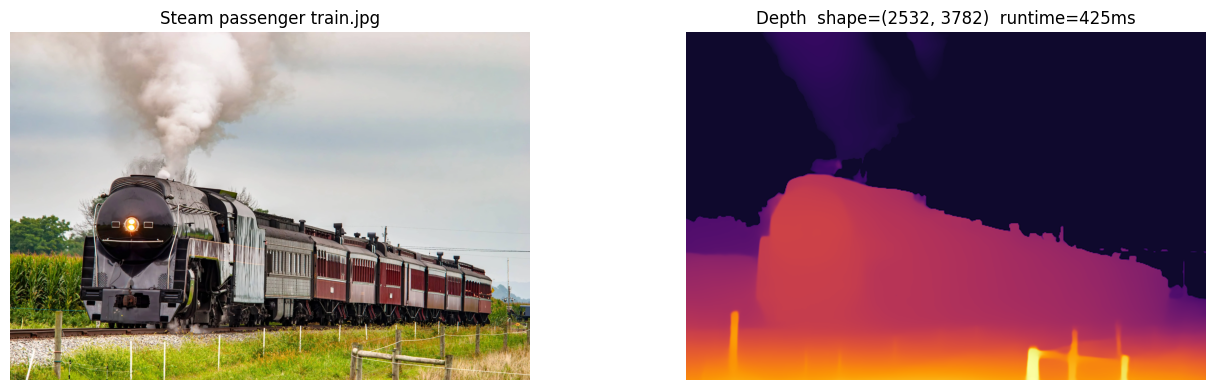

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

ok = [r for r in records if r['error'] is None]
n_show = min(4, len(ok))

fig, axes = plt.subplots(n_show, 2, figsize=(14, 4 * n_show))
if n_show == 1:
    axes = [axes]

for i, rec in enumerate(ok[:n_show]):
    img = cv2.cvtColor(cv2.imread(rec['image_path']), cv2.COLOR_BGR2RGB)
    depth = np.load(rec['pred_path'])

    axes[i][0].imshow(img)
    axes[i][0].set_title(Path(rec['image_path']).name)
    axes[i][0].axis('off')

    axes[i][1].imshow(depth, cmap='inferno')
    axes[i][1].set_title(f'Depth  shape={depth.shape}  runtime={rec["runtime_s"]*1000:.0f}ms')
    axes[i][1].axis('off')

plt.tight_layout()
plt.show()

## Smoke test passed

If you see depth maps above, the pipeline is working.

Next step: run `notebooks/01_build_kittic_manifest.ipynb` after downloading KITTI-C.